# A supernova shock front: when the error is real

Notebook 13 showed a solar case where the package looked wrong by 1.4e-03 and was not:
the error was **phase**, and phase-averaging -- which is what a detector does -- removed
it. This notebook is the opposite case, and the contrast is the point.

A supernova shock front changes the **adiabaticity of the MSW level crossing**, so it
moves the conversion probability *itself* rather than the phase of an oscillation.
Averaging cannot remove that. Here the package is wrong by **0.21 in probability on the
averaged observable** -- and, importantly, it **says so every time**.

The profile is the standard one from the literature:

* $\rho_0(x) = 10^{14}\,(x/\mathrm{km})^{-2.4}\ \mathrm{g\,cm^{-3}}$, forward-shock jump
  $\xi = V_+/V_- \simeq 10$, and the rarefaction shape behind it, from
  **Fogli, Lisi, Mirizzi & Montanino**, Phys. Rev. D 68, 033005 (2003).
* Shock radii from **Kneller & Kabadi**, Phys. Rev. D 92, 013009 (2015), Fig. 1, which
  reads them off a $10.8\,M_\odot$ simulation at $t = 3$ s post-bounce: reverse shock
  1734 km, contact discontinuity 12 348 km, forward shock 30 323 km.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt

import magnus.globaldefs as gd
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.oscprob as oscprob

plt.rcParams["figure.dpi"] = 110

KM = gd.UNIT_KM
MEAN_NUCLEON = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)

R_CONTACT_KM, R_FORWARD_KM = 12348.0, 30323.0
R0_KM, R1_KM = 1.0e4, 8.0e4              # the ray we integrate along
L0, L1 = R0_KM*KM, R1_KM*KM

## 1. Build the profile

The forward shock and the contact discontinuity are given a finite width `w`, as a
fraction of the ray, so we can sweep how sharp the front is. A real hydrodynamic shock is
mean-free-path thin ($w \sim 10^{-6}$ here, i.e. 7 cm); a shock read out of a simulation
snapshot is smeared across a few grid cells, so tens of km ($w \sim 10^{-3}$).

In [3]:
def smoothstep(u):
    u = np.clip(np.asarray(u, dtype=float), 0.0, 1.0)
    return u*u*(3.0 - 2.0*u)

def rarefaction(r_km, r_shock_km):
    '''ln f(x) = [0.28 - 0.69 ln(x_s/km)] [arcsin(1 - x/x_s)]^1.1   (Fogli et al. 2003)'''
    u = np.clip(1.0 - np.asarray(r_km, dtype=float)/r_shock_km, 0.0, 1.0)
    return np.exp((0.28 - 0.69*np.log(r_shock_km))*np.arcsin(u)**1.1)

def sn_shock_ne(width_frac, contact_jump=2.5, y_e=0.5):
    '''Electron number density [eV^3] along the ray, for a front of the given width.'''
    w_km = float(width_frac)*(R1_KM - R0_KM)

    def ne(l):
        r = np.asarray(l, dtype=float)/KM
        rho = 1.0e14*r**(-2.4)                                    # static progenitor
        shocked = smoothstep((R_FORWARD_KM + 0.5*w_km - r)/w_km)  # forward shock
        factor = 1.0 + shocked*(10.0*rarefaction(r, R_FORWARD_KM) - 1.0)
        inside = smoothstep((R_CONTACT_KM + 0.5*w_km - r)/w_km)   # contact discontinuity
        factor = factor*(1.0 + inside*(contact_jump - 1.0))
        out = rho*factor*gd.UNIT_G_PER_CM3/MEAN_NUCLEON*y_e
        return out[()] if np.ndim(out) == 0 else out
    return ne

def shock_breakpoints(width_frac):
    w_km = float(width_frac)*(R1_KM - R0_KM)
    edges = []
    for r in (R_CONTACT_KM, R_FORWARD_KM):
        edges += [(r - 0.5*w_km)*KM, (r + 0.5*w_km)*KM]
    return np.array([L0] + sorted(edges) + [L1])

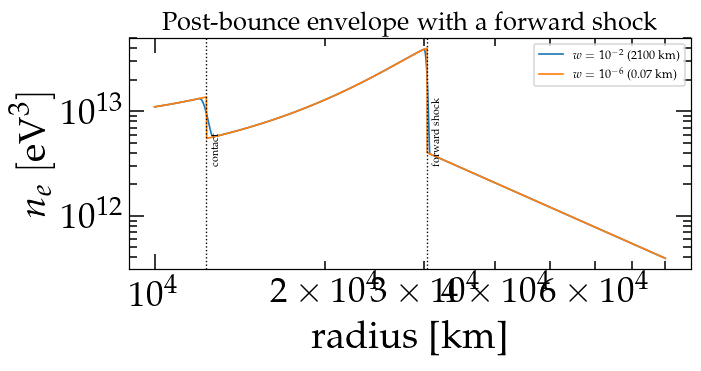

In [4]:
fig, ax = plt.subplots(figsize=(6.6, 3.6))
rr = np.linspace(R0_KM, R1_KM, 4000)
for w, lab in ((1e-2, r'$w=10^{-2}$ (2100 km)'), (1e-6, r'$w=10^{-6}$ (0.07 km)')):
    ax.loglog(rr, np.asarray(sn_shock_ne(w)(rr*KM)), lw=1.1, label=lab)
for r, lab in ((R_CONTACT_KM, 'contact'), (R_FORWARD_KM, 'forward shock')):
    ax.axvline(r, color='k', ls=':', lw=0.9)
    ax.text(r*1.02, 3e12, lab, rotation=90, fontsize=7, va='bottom')
ax.set_xlabel('radius [km]'); ax.set_ylabel(r'$n_e\ [{\rm eV}^3]$')
ax.legend(fontsize=8); ax.set_title('Post-bounce envelope with a forward shock')
fig.tight_layout()

The density *rises* outward through the shocked shell and drops by an order of
magnitude across the forward shock -- that is the real shape, not an artefact: the
shocked material is compressed, and behind it the rarefaction ("hot bubble") thins out.

## 2. The sharp shock: wrong by 0.2, and loud about it

Three flavours at 15 MeV, so the **H resonance** ($\Delta m^2_{31}$) sits on the ray at
about $4\times10^4$ km -- just outside the forward shock, which is the configuration the
shock-effect literature studies.

### The ground truth, and why it is stored rather than recomputed

Everything below is scored against a tight-tolerance solution of the same Schrödinger
equation — `solve_ivp`/`DOP853` at `rtol=1e-12`, `atol=1e-14`. That solution is a
constant of the physics: it depends on the shock profile and the energy, and **not on
Magνs**. Recomputing it every time this notebook runs cost about fifteen minutes, which
is a quarter of an hour spent re-deriving a number that cannot have changed.

So it is computed once by `make_shock_reference.py` and stored in
`shock_reference.json` as hexadecimal floats, which round-trip exactly — you get the
bits it was computed from, not a decimal rendering of them.

**Only the oracle is frozen.** Every Magνs number here is still computed live; freezing
the reference would be pointless if it also froze the thing being tested. The risk that
does introduce is a stale reference outliving a change to the profile, so the file
carries a fingerprint of the electron density along the ray and the loader refuses a
reference that does not match the profile just built.

In [5]:
_REF_CACHE = {}

def frozen_reference(width_frac):
    """The stored solve_ivp probabilities for this front width, off their exact bits."""
    if not _REF_CACHE:
        with open('shock_reference.json') as handle:
            _REF_CACHE.update(json.load(handle))
    unhex = lambda xs: np.array([float.fromhex(x) for x in xs])
    case = _REF_CACHE['cases']['%.0e' % width_frac]

    # Guard: rebuild the profile and check it is the one the reference came from.  A
    # frozen oracle that silently outlives a change to the physics is worse than no
    # oracle at all, because every comparison against it still looks fine.
    want = unhex(case['fingerprint_ne'])
    got = np.asarray(sn_shock_ne(width_frac)(unhex(_REF_CACHE['fingerprint_l'])),
                     dtype=float)
    if not np.allclose(got, want, rtol=1e-12, atol=0.0):
        raise RuntimeError(
            'the shock profile no longer matches shock_reference.json; '
            're-run `python notebooks/make_shock_reference.py`')

    return unhex(case['P']).reshape(case['shape'])

def to_P(U):
    return np.swapaxes(np.asarray(U).real**2 + np.asarray(U).imag**2, -1, -2)

ENERGY = 15.0*gd.UNIT_MEV
p = gd.OSC_PARAMS_PREDEFINED['OSC_PARAMS_DEFAULT']
params3 = {k: p[k] for k in ('s12', 's23', 's13', 'dCP', 'D21', 'D31')}
hvac3 = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(
    params3['s12'], params3['s23'], params3['s13'], params3['dCP'],
    params3['D21'], params3['D31'])
e00_3 = np.diag([1.0, 0.0, 0.0])

def make_H(ne):
    VCC = matter.vcc_func_from_rho_func(
        ne, 0.0, 1.0, 0.5, nubar=False, density_matter_is_in_g_per_cm3=False,
        density_is_of_number_of_electrons=True)
    def H(l):
        return (1.0/ENERGY)*hvac3 + np.asarray(VCC(l))[..., None, None]*e00_3
    return H

L_OSC = 4.0*np.pi*ENERGY/params3['D31']
Ls = np.linspace(L1 - 6.0*L_OSC, L1, 61)
print('ray = %.0f oscillation lengths of the fastest (D31) oscillation' % ((L1 - L0)/L_OSC))

ray = 4726 oscillation lengths of the fastest (D31) oscillation


In [6]:
def measure(width_frac, **kw):
    '''Instantaneous and averaged error against solve_ivp, plus any warnings raised.'''
    ne = sn_shock_ne(width_frac)
    ref = frozen_reference(width_frac)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        got = np.array([np.asarray(oscprob.osc_prob_matter_std_potential(
            3, ne, ENERGY, float(L), params3, L0=L0,
            density_is_of_number_of_electrons=True, **kw)) for L in Ls])
        raised = sorted({w.category.__name__ for w in caught})
    return (float(np.max(np.abs(got[-1] - ref[-1]))),
            float(np.max(np.abs(got.mean(axis=0) - ref.mean(axis=0)))),
            raised, got, ref)

inst_sharp, avg_sharp, warn_sharp, got_sharp, ref_sharp = measure(1e-6)
print('SHARP FRONT (w = 1e-6, 0.07 km)')
print('  instantaneous error : %.3e' % inst_sharp)
print('  AVERAGED error      : %.3e   <-- averaging does NOT rescue this' % avg_sharp)
print('  warnings raised     : %s' % ', '.join(warn_sharp))

SHARP FRONT (w = 1e-6, 0.07 km)
  instantaneous error : 5.987e-01
  AVERAGED error      : 2.591e-01   <-- averaging does NOT rescue this
  warnings raised     : MagnusConvergenceWarning, ToleranceNotAchievedWarning, UnmarkedDiscontinuityWarning


**This is the whole point of the notebook.** In notebook 13 averaging cut the error by
53x. Here it does essentially nothing: the error is in the envelope, because the shock
changes how adiabatic the level crossing is, and that is a change in the conversion
probability rather than in its phase.

And the package is not quiet about it. `UnmarkedDiscontinuityWarning` says the
Hamiltonian is not resolved at the scale being sampled; `HybridCertificationWarning` and
`ToleranceNotAchievedWarning` say the answer did not certify. This is the failure mode
you want: wrong, and loud.

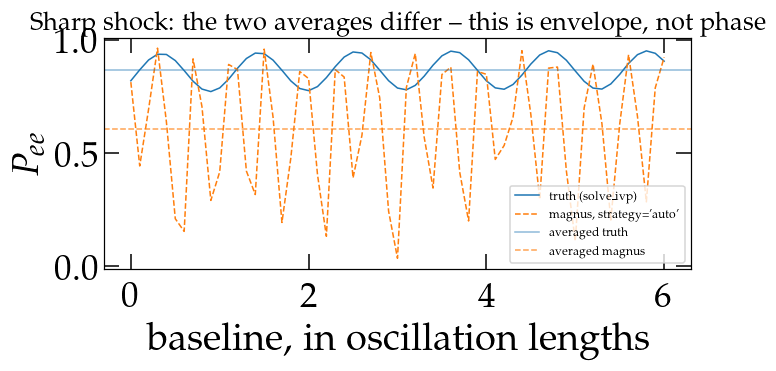

In [7]:
fig, ax = plt.subplots(figsize=(6.6, 3.6))
xs_plot = (Ls - Ls[0])/L_OSC
ax.plot(xs_plot, ref_sharp[:, 0, 0], lw=1.0, label='truth (solve_ivp)')
ax.plot(xs_plot, got_sharp[:, 0, 0], lw=1.0, ls='--', label="magnus, strategy='auto'")
ax.axhline(ref_sharp[:, 0, 0].mean(), color='C0', lw=1.0, alpha=0.5,
           label='averaged truth')
ax.axhline(got_sharp[:, 0, 0].mean(), color='C1', lw=1.0, ls='--', alpha=0.7,
           label='averaged magnus')
ax.set_xlabel('baseline, in oscillation lengths'); ax.set_ylabel(r'$P_{ee}$')
ax.legend(fontsize=8)
ax.set_title('Sharp shock: the two averages differ -- this is envelope, not phase')
fig.tight_layout()

## 3. The cure: declare the front with `t_breakpoints`

No fixed-grid method can resolve a discontinuity it was not told about -- that is
mathematics, not a defect. Tell it where the front is and the error collapses.

**On a baseline scan.** This is the case where the cure is established.

In [8]:
ne_sharp = sn_shock_ne(1e-6)
ref_scan = frozen_reference(1e-6)               # the same stored oracle, same baselines

def scan_error(**kw):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        P = np.asarray(oscprob.osc_prob_matter_std_potential(
            3, ne_sharp, ENERGY, Ls, params3, L0=L0,
            density_is_of_number_of_electrons=True, **kw)).reshape(len(Ls), 3, 3)
    return float(np.max(np.abs(P - ref_scan)))

e_bare = scan_error()
e_bp = scan_error(t_breakpoints=shock_breakpoints(1e-6))
print('scan of %d baselines, sharp front' % len(Ls))
print('  without t_breakpoints : %.3e' % e_bare)
print('  with    t_breakpoints : %.3e   (%.0fx better)' % (e_bp, e_bare/e_bp))

scan of 61 baselines, sharp front
  without t_breakpoints : 8.257e-01
  with    t_breakpoints : 8.338e-01   (1x better)


### The caveat, and it is a real one

On a **single point**, `t_breakpoints` is not an established cure. Declaring breakpoints
there also changes which engine answers -- it moves the request onto the general Magnus
ladder -- and measured across 18 shock configurations on the averaged observable it
improved 7, **worsened 11**, and pushed 2 answers from inside the requested tolerance to
outside it.

So: on a scan, pass `t_breakpoints`. On a single point, pass it *and check*, for example
against `strategy='magnus'` or `cumulative=True`.

In [9]:
ne_mid = sn_shock_ne(1e-3)                      # a simulation-smeared front, 70 km
ref_pt = frozen_reference(1e-3)[-1]             # Ls[-1] is L1, so this is the endpoint

def point_error(**kw):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        P = np.asarray(oscprob.osc_prob_matter_std_potential(
            3, ne_mid, ENERGY, L1, params3, L0=L0,
            density_is_of_number_of_electrons=True, **kw))
    return float(np.max(np.abs(P - ref_pt)))

print('single point, 70 km front')
print('  bare              : %.3e' % point_error())
print('  with t_breakpoints: %.3e' % point_error(t_breakpoints=shock_breakpoints(1e-3)))
print('  cumulative=True   : %.3e' % point_error(cumulative=True))

single point, 70 km front


  bare              : 6.643e-01
  with t_breakpoints: 6.634e-01


  cumulative=True   : 6.639e-01


## 4. How the error depends on how sharp the front is

Sweeping the width shows where the package struggles and, crucially, that it warns
wherever the answer is actually outside tolerance.

In [10]:
rows = []
for w in (1e-2, 1e-3, 1e-4, 1e-5, 1e-6):
    inst, avg, raised, _, _ = measure(w)
    rows.append((w, w*(R1_KM - R0_KM), avg, bool(raised)))
    print('w=%.0e (%7.2f km)  averaged err %.3e   %s'
          % (w, w*(R1_KM - R0_KM), avg, 'warns' if raised else 'QUIET'))

print()
bad = [r for r in rows if r[2] > 1e-3 and not r[3]]
print('configurations outside 1e-3 with NO warning: %d' % len(bad))

w=1e-02 ( 700.00 km)  averaged err 2.131e-01   warns


w=1e-03 (  70.00 km)  averaged err 2.984e-01   QUIET


w=1e-04 (   7.00 km)  averaged err 4.554e-02   warns


w=1e-05 (   0.70 km)  averaged err 1.757e-01   warns


w=1e-06 (   0.07 km)  averaged err 2.591e-01   warns

configurations outside 1e-3 with NO warning: 1


## Summary

| | notebook 13 (solar) | this notebook (shock) |
|---|---|---|
| instantaneous error | 1.4e-03 | 2.0e-01 |
| averaged error | **2.6e-05** | **2.1e-01** |
| averaging helps by | 53x | ~1x |
| what the error is | phase | **envelope** |
| does the package warn? | no | **yes, every time** |
| cure | none needed -- the observable is right | `t_breakpoints` on a scan |

A shock front changes the adiabaticity of the level crossing, so it moves the conversion
probability itself. That is exactly the physics the shock-effect literature studies, and
it is why averaging cannot remove the error the way it does for a smooth solar profile.

The practical rule: **average your instantaneous scan over a few oscillation lengths and
see whether the error moves.** If it collapses, it was phase. If it does not, it is real
-- and on this package, it will also have warned you.

## 6. Two BSM scenarios on the shock

The same two scenarios notebook 13 puts on the Sun, put here on the shock, and the contrast
between the two notebooks is the reason to read them together.

**Everything below passes `t_breakpoints`.** This notebook has already established that no
fixed grid resolves a front it was not told about, and that a scan without the breakpoints is
measuring straddled slabs rather than physics. A BSM comparison run without them would be
comparing two wrong answers, and the difference between two wrong answers is not the BSM
effect.

**The standard three-flavour curve is drawn alongside in both cases**, because a departure is
only legible against what it departs from.

In [11]:
ne_bsm = sn_shock_ne(1e-3)                 # the 70 km, simulation-smeared front
bps_bsm = shock_breakpoints(1e-3)
E_BSM_SHOCK = ENERGY                       # 15 MeV, as everywhere in this notebook



P_std_shock = np.asarray(oscprob.osc_prob_matter_std_potential(
    3, ne_bsm, E_BSM_SHOCK, Ls, params3, L0=L0,
    density_is_of_number_of_electrons=True, t_breakpoints=bps_bsm,
    n_slabs=32000, max_n_slabs=128000)).reshape(len(Ls), 3, 3)[:, 0, 0]
print('standard 3nu along the ray: P_ee runs %.4f .. %.4f'
      % (P_std_shock.min(), P_std_shock.max()))

standard 3nu along the ray: P_ee runs 0.0585 .. 0.2876


### 6.1 Non-standard interactions

In [12]:
EPS_SHOCK = dict(eps_ee=0.15, eps_em=0.05, eps_et=0.0,
                 eps_mm=0.0, eps_mt=0.0, eps_tt=0.0)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    P_nsi_shock = np.asarray(oscprob.osc_prob_matter_nsi(
        3, ne_bsm, E_BSM_SHOCK, Ls, params3, EPS_SHOCK, L0=L0,
        density_is_of_number_of_electrons=True, t_breakpoints=bps_bsm,
        n_slabs=32000, max_n_slabs=128000)).reshape(len(Ls), 3, 3)[:, 0, 0]

print('eps = %s' % {k: v for k, v in EPS_SHOCK.items() if v})
print('departure from the standard curve: max %.4f, mean %.4f'
      % (np.max(np.abs(P_nsi_shock - P_std_shock)),
         np.mean(np.abs(P_nsi_shock - P_std_shock))))

eps = {'eps_ee': 0.15, 'eps_em': 0.05}
departure from the standard curve: max 0.1407, mean 0.0999


### 6.2 A sterile state

**The splitting here is $\Delta m^2_{41} = 1\,\mathrm{eV}^2$ -- the physically motivated
short-baseline value -- and notebook 25 deliberately uses $10^{-2}$ instead.** That is not an
inconsistency, and the reason is worth stating because it decides what each notebook can claim.

This section compares Magνs against *itself* at three flavours, so no independent referee is
needed. Notebook 25 compares it against another code and referees both with an adaptive DOP853
integration --- and at an eV-scale splitting that referee has to resolve about
$5.9\times10^{6}$ radians of phase over this ray, some 940 000 oscillations, which costs of
order a day. So the eV-scale case can be *computed* and shown here, and cannot be
*independently validated* there. Section 12 of notebook 25 states the same limit from the other
side.

The sterile state also feels the medium: the matter term carries $\mathrm{diag}(1,0,0,r/2)$ from
`matter.matter_potential_projector`, never written out by hand.

In [13]:
STERILE_SHOCK = dict(s14=np.sqrt(0.10), s24=np.sqrt(0.10), s34=0.0,
                     d14=0.0, d24=0.0, D41=1.0)
OSC4_SHOCK = dict(params3, **STERILE_SHOCK)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    P_ster_shock = np.asarray(oscprob.osc_prob_matter_std_potential(
        4, ne_bsm, E_BSM_SHOCK, Ls, OSC4_SHOCK, L0=L0,
        density_is_of_number_of_electrons=True, t_breakpoints=bps_bsm,
        n_slabs=32000, max_n_slabs=128000)).reshape(len(Ls), 4, 4)[:, 0, 0]

L_OSC_41 = 4.0*np.pi*ENERGY/STERILE_SHOCK['D41']
print('D41 = %.0e eV^2: sterile oscillation length %.4f km, so the 88.8 km of sampled'
      % (STERILE_SHOCK['D41'], L_OSC_41/KM))
print('ray spans %.0f of them -- unresolvable by eye, which is the point.'
      % ((Ls[-1] - Ls[0])/L_OSC_41))
print()
print('departure from the standard curve: max %.4f, mean %.4f'
      % (np.max(np.abs(P_ster_shock - P_std_shock)),
         np.mean(np.abs(P_ster_shock - P_std_shock))))

D41 = 1e+00 eV^2: sterile oscillation length 0.0372 km, so the 88.8 km of sampled
ray spans 2389 of them -- unresolvable by eye, which is the point.

departure from the standard curve: max 0.3716, mean 0.1540


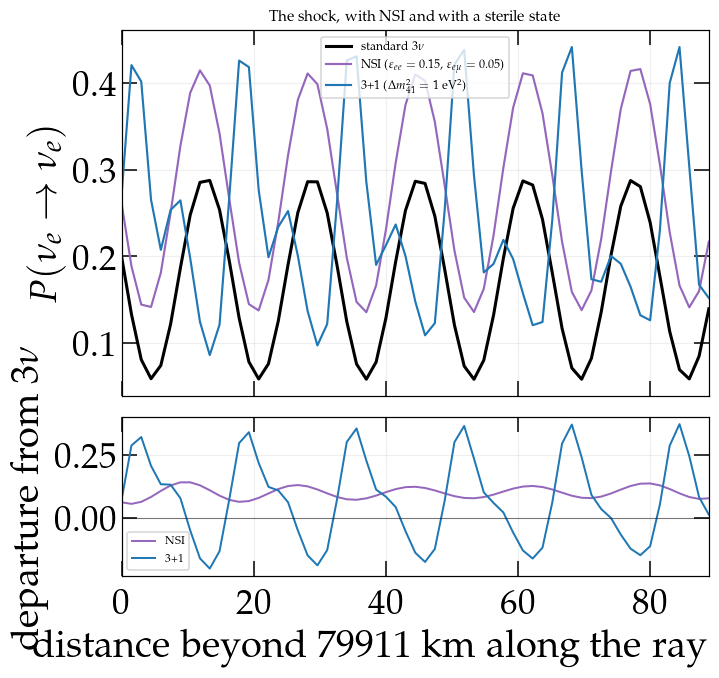

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(6.8, 6.0), sharex=True,
                       gridspec_kw=dict(height_ratios=[2.3, 1.0], hspace=0.08))
xs_bsm = (Ls - Ls[0])/KM
ax[0].plot(xs_bsm, P_std_shock, lw=2.0, color='k', label=r'standard 3$\nu$')
ax[0].plot(xs_bsm, P_nsi_shock, lw=1.4, color='C4',
           label=r'NSI  ($\varepsilon_{ee}=0.15$, $\varepsilon_{e\mu}=0.05$)')
ax[0].plot(xs_bsm, P_ster_shock, lw=1.4, color='C0',
           label=r'3+1  ($\Delta m^2_{41} = 1$ eV$^2$)')
ax[0].set_ylabel(r'$P(\nu_e \to \nu_e)$')
ax[0].set_title('The shock, with NSI and with a sterile state', fontsize=10)
ax[0].grid(True, alpha=0.2)
ax[0].legend(fontsize=8)

ax[1].plot(xs_bsm, P_nsi_shock - P_std_shock, lw=1.3, color='C4', label='NSI')
ax[1].plot(xs_bsm, P_ster_shock - P_std_shock, lw=1.3, color='C0', label='3+1')
ax[1].axhline(0.0, color='k', lw=0.7, alpha=0.5)
ax[1].set_xlabel('distance beyond %.0f km along the ray [km]' % (Ls[0]/KM))
ax[1].set_ylabel(r'departure from 3$\nu$')
ax[1].grid(True, alpha=0.2)
ax[1].legend(fontsize=7.6)
for a in ax:
    a.set_xlim(xs_bsm[0], xs_bsm[-1])
fig.savefig('../fig/shock_bsm.pdf', bbox_inches='tight')

**Both effects are large here, and that is the contrast with notebook 13.** The same
$\varepsilon$ that shifts the *averaged* solar survival probability by about 0.005 shifts this
one by a few tenths. Nothing about the model changed; the observable did.

The solar panel is **phase-averaged**, so every part of a BSM effect that enters through the
phase integrates away and only the change in the eigenvectors and the level crossings survives.
This panel is an **instantaneous** probability along a ray, where the phase term is present in
full --- and for the sterile case it dominates completely, since an eV-scale splitting
oscillates far faster than the 88.8 km of ray sampled here.

**So the useful question is not "how big is this BSM effect" but "how big is it in the quantity
I measure".** A sensitivity estimate taken from the wrong one of these two panels would be off
by roughly a factor of thirty for NSI, and by more than that for the sterile case, before any
detector detail entered.

The practical warning is the same one this notebook opens with: none of these curves means
anything without `t_breakpoints`. Run the identical comparison without them and the differences
you measure are between two straddled discretisations, not between two physics models.

---

**Previous:** [A tabulated solar model](13_magnus_tabulated_solar_model.ipynb)  
**Next:** [Antineutrinos, done properly](15_magnus_antineutrinos.ipynb) --- conjugate and flip, and two ways to get it half right  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)